
# Regime Detection and Adaptive Trading 📈📊💱
 **Proyecto:** Detección de Régimen y Trading Adaptativo  

 **Autor:** Francisco Encina  

 **Profesor:** Nicolás Torres

 **Curso:** Aprendizaje de Máquinas - IPD440

 **Universidad Técnica Federico Santa María**

---

## 📋 Estructura del Proyecto

1. **Data Extraction & Feature Engineering**
2. **Regime Detection (HMM)**
3. **ML Models por Régimen**
4. **Trading Strategy & Backtesting**

*This notebook contains: Data Extraction & Feature Engineering*


In [ ]:
# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


### 1.1 Descarga de Datos

In [ ]:
def download_market_data(ticker='SPY', start_date='1993-01-01', end_date=None):
    """
    Descarga datos históricos de Yahoo Finance

    Args:
        ticker: Símbolo del activo (default: SPY para S&P 500)
        start_date: Fecha inicial
        end_date: Fecha final (default: hoy)

    Returns:
        DataFrame con OHLCV data
    """
    if end_date is None:
        end_date = datetime.now().strftime('%Y-%m-%d')

    print(f"📥 Descargando {ticker} desde {start_date} hasta {end_date}...")

    data = yf.download(ticker, start=start_date, end=end_date, progress=False)

    print(f"✓ Datos descargados: {len(data)} días")
    print(f"  Rango: {data.index[0].date()} → {data.index[-1].date()}")

    return data

# Descargar datos
ticker = 'SPY'
raw_data = download_market_data(ticker=ticker, start_date='1993-01-01')

# FIX: Reconstruir DataFrame forzando Series
data = pd.DataFrame({
    'Open': raw_data['Open'].values.flatten() if hasattr(raw_data['Open'], 'values') else raw_data['Open'],
    'High': raw_data['High'].values.flatten() if hasattr(raw_data['High'], 'values') else raw_data['High'],
    'Low': raw_data['Low'].values.flatten() if hasattr(raw_data['Low'], 'values') else raw_data['Low'],
    'Close': raw_data['Close'].values.flatten() if hasattr(raw_data['Close'], 'values') else raw_data['Close'],
    'Volume': raw_data['Volume'].values.flatten() if hasattr(raw_data['Volume'], 'values') else raw_data['Volume'],
}, index=raw_data.index)

# Agregar Adj Close
data['Adj Close'] = data['Close']

# Verificar que TODO sea Serie
print("Verificación de tipos:")
for col in data.columns:
    print(f"  {col}: {type(data[col])}")

# Preview
print("\n📊 Preview de datos crudos:")
print(data.tail())

📥 Descargando SPY desde 1993-01-01 hasta 2025-12-29...
✓ Datos descargados: 8285 días
  Rango: 1993-01-29 → 2025-12-26
Verificación de tipos:
  Open: <class 'pandas.core.series.Series'>
  High: <class 'pandas.core.series.Series'>
  Low: <class 'pandas.core.series.Series'>
  Close: <class 'pandas.core.series.Series'>
  Volume: <class 'pandas.core.series.Series'>
  Adj Close: <class 'pandas.core.series.Series'>

📊 Preview de datos crudos:
               Open     High      Low    Close     Volume  Adj Close
Date                                                                
2025-12-19 676.5900 681.0900 676.4700 680.5900  103599500   680.5900
2025-12-22 683.9400 685.3600 680.5900 684.8300   69556700   684.8300
2025-12-23 683.9200 688.2000 683.8700 687.9600   64840000   687.9600
2025-12-24 687.9500 690.8300 687.8000 690.3800   39445600   690.3800
2025-12-26 690.6400 691.6600 689.2700 690.3100   41588400   690.3100


### 1.2 Feature Engineering

In [ ]:
def calculate_features(data):
    """
    Calcula features para detección de régimen y ML
    """
    df = data.copy()

    # FIX: Aplanar TODAS las columnas a Series
    for col in df.columns:
        if isinstance(df[col], pd.DataFrame):
            df[col] = df[col].iloc[:, 0]

    # ==================
    # RETORNOS
    # ==================
    df['Returns'] = df['Adj Close'].pct_change()
    df['Log_Returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

    # ==================
    # VOLATILIDAD
    # ==================
    df['Volatility_5'] = df['Returns'].rolling(5).std() * np.sqrt(252)
    df['Volatility_20'] = df['Returns'].rolling(20).std() * np.sqrt(252)
    df['Volatility_60'] = df['Returns'].rolling(60).std() * np.sqrt(252)

    # ==================
    # MOMENTUM
    # ==================
    df['Momentum_5'] = df['Adj Close'].pct_change(5)
    df['Momentum_10'] = df['Adj Close'].pct_change(10)
    df['Momentum_20'] = df['Adj Close'].pct_change(20)
    df['Momentum_60'] = df['Adj Close'].pct_change(60)

    # ==================
    # MOVING AVERAGES
    # ==================
    df['SMA_20'] = df['Adj Close'].rolling(20).mean()
    df['SMA_50'] = df['Adj Close'].rolling(50).mean()
    df['SMA_200'] = df['Adj Close'].rolling(200).mean()

    # Price relative to SMAs
    df['Price_to_SMA20'] = df['Adj Close'] / df['SMA_20'] - 1
    df['Price_to_SMA50'] = df['Adj Close'] / df['SMA_50'] - 1
    df['Price_to_SMA200'] = df['Adj Close'] / df['SMA_200'] - 1

    # ==================
    # VOLUMEN
    # ==================
    df['Volume_MA20'] = df['Volume'].rolling(20).mean()
    df['Volume_Ratio'] = (df['Volume'] / df['Volume_MA20']).fillna(1.0).replace([np.inf, -np.inf], 1.0)

    # ==================
    # RSI (Relative Strength Index)
    # ==================
    delta = df['Adj Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # Drop NaNs
    df = df.dropna()

    print(f"\n✓ Features calculados: {len(df.columns)} columnas")
    print(f"✓ Datos válidos: {len(df)} días")

    return df

# Calcular features
df = calculate_features(data)

# Preview de features importantes
print("\n📊 Features principales (últimas 5 filas):")
df[['Adj Close', 'Returns', 'Volatility_20', 'Momentum_20', 'RSI']].tail()


✓ Features calculados: 24 columnas
✓ Datos válidos: 8086 días

📊 Features principales (últimas 5 filas):


,Adj Close,Returns,Volatility_20,Momentum_20,RSI
Date,,,,,
2025-12-19,680.5900,0.0091,0.1070,0.0461,52.6998
2025-12-22,684.8300,0.0062,0.1042,0.0422,55.7660
2025-12-23,687.9600,0.0046,0.0936,0.0318,56.5003
2025-12-24,690.3800,0.0035,0.0893,0.0258,58.2157
2025-12-26,690.3100,-0.0001,0.0869,0.0186,56.9897


### 1.3 Análisis Exploratorio (EDA)

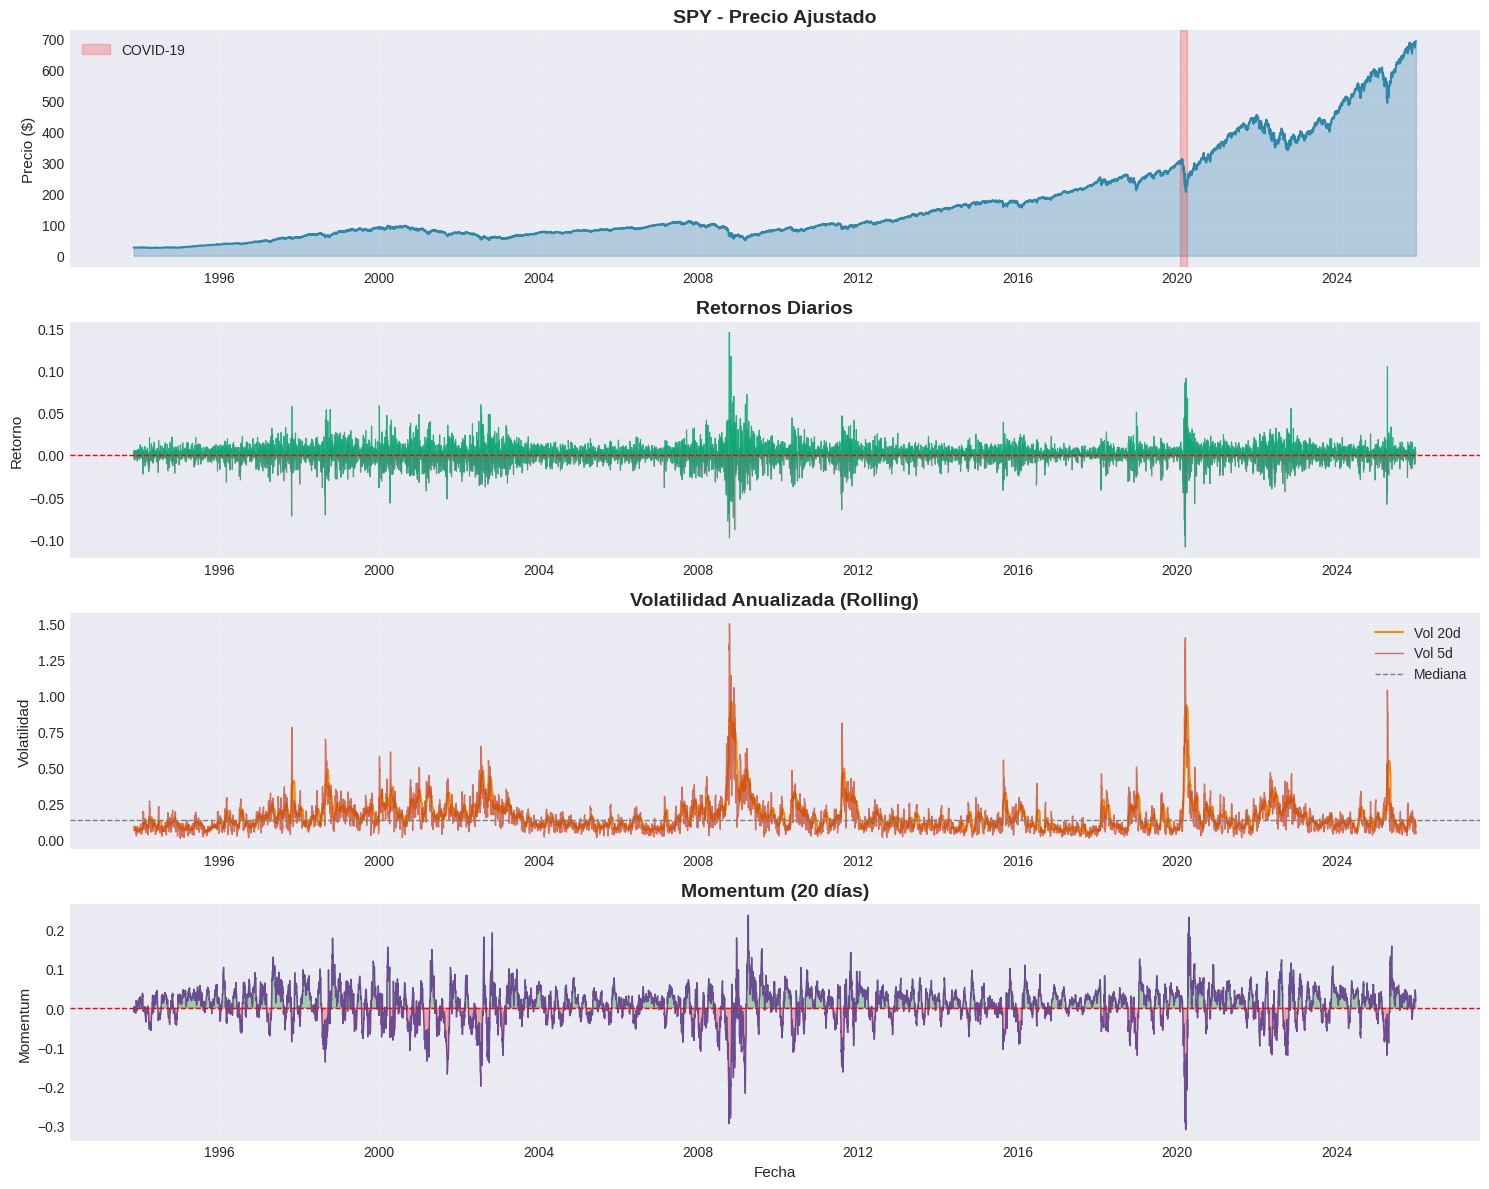

In [ ]:
def plot_eda(df, ticker='SPY'):
    """
    Visualizaciones exploratorias
    """
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))

    # 1. PRECIO
    axes[0].plot(df.index, df['Adj Close'], linewidth=1.5, color='#2E86AB')
    axes[0].fill_between(df.index, df['Adj Close'], alpha=0.3, color='#2E86AB')
    axes[0].set_title(f'{ticker} - Precio Ajustado', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Precio ($)', fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Marcar eventos conocidos
    axes[0].axvspan('2020-02-01', '2020-04-01', alpha=0.2, color='red', label='COVID-19')
    axes[0].legend()

    # 2. RETORNOS
    axes[1].plot(df.index, df['Returns'], linewidth=0.7, color='#06A77D', alpha=0.8)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[1].fill_between(df.index, df['Returns'], 0,
                         where=(df['Returns'] > 0), alpha=0.3, color='green')
    axes[1].fill_between(df.index, df['Returns'], 0,
                         where=(df['Returns'] < 0), alpha=0.3, color='red')
    axes[1].set_title('Retornos Diarios', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Retorno', fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # 3. VOLATILIDAD
    axes[2].plot(df.index, df['Volatility_20'], linewidth=1.5,
                 color='#F18F01', label='Vol 20d')
    axes[2].plot(df.index, df['Volatility_5'], linewidth=1,
                 color='#C73E1D', alpha=0.7, label='Vol 5d')
    axes[2].axhline(y=df['Volatility_20'].median(), color='gray',
                    linestyle='--', linewidth=1, label='Mediana')
    axes[2].set_title('Volatilidad Anualizada (Rolling)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Volatilidad', fontsize=11)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # 4. MOMENTUM
    axes[3].plot(df.index, df['Momentum_20'], linewidth=1, color='#6A4C93')
    axes[3].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[3].fill_between(df.index, df['Momentum_20'], 0,
                         where=(df['Momentum_20'] > 0), alpha=0.3, color='green')
    axes[3].fill_between(df.index, df['Momentum_20'], 0,
                         where=(df['Momentum_20'] < 0), alpha=0.3, color='red')
    axes[3].set_title('Momentum (20 días)', fontsize=14, fontweight='bold')
    axes[3].set_ylabel('Momentum', fontsize=11)
    axes[3].set_xlabel('Fecha', fontsize=11)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Generar visualizaciones
plot_eda(df, ticker)

In [ ]:
def print_summary_stats(df):
    """
    Estadísticas descriptivas del mercado
    """
    print("="*70)
    print("📊 ESTADÍSTICAS DESCRIPTIVAS")
    print("="*70)

    # Retornos
    annual_return = df['Returns'].mean() * 252
    annual_vol = df['Returns'].std() * np.sqrt(252)
    sharpe = annual_return / annual_vol

    print(f"\n💰 RETORNOS:")
    print(f"   Retorno anualizado:      {annual_return:>8.2%}")
    print(f"   Volatilidad anualizada:  {annual_vol:>8.2%}")
    print(f"   Sharpe Ratio (rf=0):     {sharpe:>8.2f}")
    print(f"   Skewness:                {df['Returns'].skew():>8.2f}")
    print(f"   Kurtosis:                {df['Returns'].kurtosis():>8.2f}")

    # Drawdown
    cum_returns = (1 + df['Returns']).cumprod()
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()

    print(f"\n📉 DRAWDOWN:")
    print(f"   Max Drawdown:            {max_dd:>8.2%}")

    # Distribución de retornos
    positive_days = (df['Returns'] > 0).sum()
    negative_days = (df['Returns'] < 0).sum()
    total_days = len(df)

    print(f"\n📅 DISTRIBUCIÓN:")
    print(f"   Días positivos:          {positive_days:>5} ({positive_days/total_days:>6.1%})")
    print(f"   Días negativos:          {negative_days:>5} ({negative_days/total_days:>6.1%})")
    print(f"   Total días:              {total_days:>5}")

    # Volatilidad
    print(f"\n📊 VOLATILIDAD:")
    print(f"   Volatilidad media (20d): {df['Volatility_20'].mean():>8.2%}")
    print(f"   Volatilidad min (20d):   {df['Volatility_20'].min():>8.2%}")
    print(f"   Volatilidad max (20d):   {df['Volatility_20'].max():>8.2%}")

    print("\n" + "="*70)

# Imprimir estadísticas
print_summary_stats(df)

📊 ESTADÍSTICAS DESCRIPTIVAS

💰 RETORNOS:
   Retorno anualizado:        11.98%
   Volatilidad anualizada:    18.80%
   Sharpe Ratio (rf=0):         0.64
   Skewness:                   -0.01
   Kurtosis:                   11.66

📉 DRAWDOWN:
   Max Drawdown:             -55.19%

📅 DISTRIBUCIÓN:
   Días positivos:           4388 ( 54.3%)
   Días negativos:           3647 ( 45.1%)
   Total días:               8086

📊 VOLATILIDAD:
   Volatilidad media (20d):   16.02%
   Volatilidad min (20d):      3.19%
   Volatilidad max (20d):     95.92%



### 1.4 Guardar Datos Procesados

In [ ]:
# Guardar para usar después
df.to_csv('data_processed.csv')
print("✓ Datos guardados en 'data_processed.csv'")

✓ Datos guardados en 'data_processed.csv'
